# TP3 (a completer) : Regression lineaire — *California Housing*

Remplacez chaque `...` et chaque `# TODO`. Corrige :
`../notebooks/TP3_regression_lineaire.ipynb`.

**Objectif.** Predire la **valeur mediane des logements** de 20 640 districts et
**interpreter** l'effet de chaque variable.

In [1]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [2]:
from sklearn.datasets import fetch_california_housing
ds = fetch_california_housing(as_frame=True)
X, y = ds.data, ds.target.rename("prix")   # prix en x100 000 USD
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 1. Exploration
**Consigne.** Affichez la correlation de chaque variable avec `prix`, triee.

In [3]:
correlations = pd.concat([X, y], axis=1).corr()["prix"].sort_values(ascending=False)
print(correlations)

prix          1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: prix, dtype: float64


## 2. Modelisation
**Consigne.** Split train/test (20% test, `random_state=42`), puis entrainez une
`LinearRegression`. Affichez l'ordonnee a l'origine et les coefficients.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modele = LinearRegression().fit(X_train, y_train)

print("Ordonnee a l'origine (intercept) :", modele.intercept_)
print("\nCoefficients :")
print(pd.Series(modele.coef_, index=X.columns))

Ordonnee a l'origine (intercept) : -37.023277706064235

Coefficients :
MedInc        0.448675
HouseAge      0.009724
AveRooms     -0.123323
AveBedrms     0.783145
Population   -0.000002
AveOccup     -0.003526
Latitude     -0.419792
Longitude    -0.433708
dtype: float64


## 3. Evaluation
**Consigne.** Calculez **R2**, **RMSE** et **MAE** sur le test.

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = modele.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R2   : {r2:.3f}")
print(f"RMSE : {rmse:.3f}  (soit ~{rmse*100:.0f}k USD)")
print(f"MAE  : {mae:.3f}  (soit ~{mae*100:.0f}k USD)")

R2   : 0.576
RMSE : 0.746  (soit ~75k USD)
MAE  : 0.533  (soit ~53k USD)


## 4. Visualisation
**Consigne.** (a) Tracez `prix` vs `MedInc` avec la droite de regression simple.
(b) Tracez **predit vs reel** sur un echantillon. (c) Tracez les **residus**.

/Users/romaintoso/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


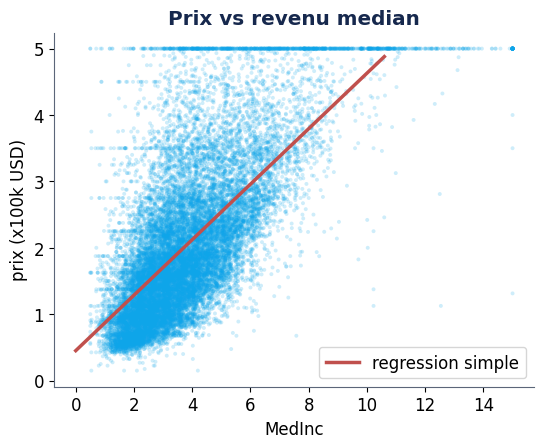

In [6]:
# (a) prix vs MedInc + droite
simple = LinearRegression().fit(X[["MedInc"]], y)
xs = np.linspace(0, X["MedInc"].quantile(0.99), 100).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.scatter(X["MedInc"], y, s=8, color=ACCENT, alpha=0.2, edgecolor="none")
ax.plot(xs, simple.predict(xs), color=RED, lw=2.5, label="regression simple")
ax.legend()
ax.set(title="Prix vs revenu median", xlabel="MedInc", ylabel="prix (x100k USD)")
plt.show()

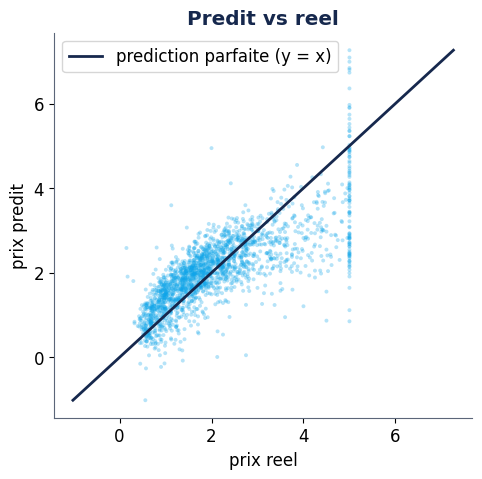

In [7]:
# (b) predit vs reel (echantillon de 2000 points)
rng = np.random.default_rng(0)
idx = rng.choice(len(y_test), 2000, replace=False)
yt, yp = y_test.to_numpy()[idx], y_pred[idx]
fig, ax = plt.subplots(figsize=(5.4, 5))
ax.scatter(yt, yp, s=8, color=ACCENT, alpha=0.3, edgecolor="none")
lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
ax.plot(lims, lims, color=NAVY, lw=2, label="prediction parfaite (y = x)")
ax.legend()
ax.set(title="Predit vs reel", xlabel="prix reel", ylabel="prix predit")
plt.show()

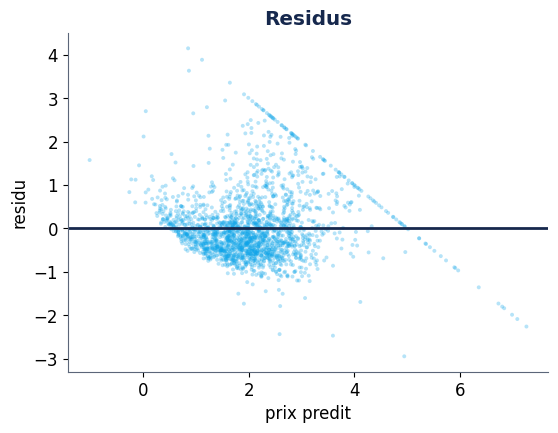

In [8]:
# (c) residus
residus = yt - yp
fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.axhline(0, color=NAVY, lw=2)
ax.scatter(yp, residus, s=8, color=ACCENT, alpha=0.3, edgecolor="none")
ax.set(title="Residus", xlabel="prix predit", ylabel="residu")
plt.show()

## 5. Interpretation
**Consigne.** Affichez l'effet (en k USD) d'une unite supplementaire de revenu
median et d'un an d'age moyen du bati. Estimez le prix de 3 districts.

In [9]:
coefs = pd.Series(modele.coef_, index=X.columns)
print(f"+1 unite de revenu median (MedInc) -> {coefs['MedInc']*100:+.1f} k USD sur le prix")
print(f"+1 an d'age moyen du bati (HouseAge) -> {coefs['HouseAge']*100:+.1f} k USD sur le prix")

estim = X.head(3).copy()
estim["prix_estime"] = modele.predict(X.head(3))
estim

+1 unite de revenu median (MedInc) -> +44.9 k USD sur le prix
+1 an d'age moyen du bati (HouseAge) -> +1.0 k USD sur le prix


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,prix_estime
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.151943
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.999520
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.673580


## A rendre
- R2, RMSE, MAE et leur interpretation.
- Ce que revele le graphique des residus (indice : effet de plafond).
- L'effet du revenu median sur le prix.

**Bonus.** Comparez le R2 avec une seule variable (`MedInc`) vs toutes.

In [10]:
Xm_train, Xm_test = X_train[["MedInc"]], X_test[["MedInc"]]
modele_simple = LinearRegression().fit(Xm_train, y_train)

r2_simple = r2_score(y_test, modele_simple.predict(Xm_test))
r2_complet = r2_score(y_test, y_pred)

print(f"R2 avec MedInc seul     : {r2_simple:.3f}")
print(f"R2 avec toutes les vars : {r2_complet:.3f}")
print(f"Gain apporte par les autres variables : {r2_complet - r2_simple:+.3f}")

R2 avec MedInc seul     : 0.459
R2 avec toutes les vars : 0.576
Gain apporte par les autres variables : +0.117
